# 12. Factorial Kriging 

**Dataset:** Jura geochemical survey (`data/jura_data.csv`, 359 samples) + prediction grid (`data/jura_grid.csv`)

**Target:** Cadmium (Cd, mg/kg) -- separating its short-range and long-range spatial structures

**Library:** `pygstat.factorial_kriging` -- Matheron's Factorial Kriging Analysis (Matheron, 1982; Sandjivy, 1984)

***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory — Nested Models as Sums of Orthogonal Factors](#2-theory--nested-models-as-sums-of-orthogonal-factors)
3. [Theory — The Factorial Kriging System](#3-theory--the-factorial-kriging-system)
4. [Theory — A Subtlety Worth Getting Right](#4-theory--a-subtlety-worth-getting-right)
5. [Python Setup](#5-python-setup)
6. [Load the Jura Cd Data and Prediction Grid](#6-load-the-jura-cd-data-and-prediction-grid)
7. [Step 1 — Fit a Nested (Nugget + Short + Long) Variogram](#7-step-1--fit-a-nested-nugget--short--long-variogram)
8. [Step 2 — Sanity Checks Before Trusting the Maps](#8-step-2--sanity-checks-before-trusting-the-maps)
9. [Step 3 — Map the Total, Short-Range, and Long-Range Factors](#9-step-3--map-the-total-short-range-and-long-range-factors)
10. [Step 4 — Quantify the Scale Separation](#10-step-4--quantify-the-scale-separation)
11. [Step 5 — Filtering the Nugget: a Denoised Cd Map](#11-step-5--filtering-the-nugget-a-denoised-cd-map)
12. [CPU vs GPU Factorial Kriging Timing](#12-cpu-vs-gpu-factorial-kriging-timing)
13. [Summary and Conclusions](#13-summary-and-conclusions)
14. [Resources](#14-resources)


***
## 1. Overview

A fitted variogram is almost always **nested** -- a nugget plus one or more bounded
structures, each with its own range. Ordinary kriging uses the *sum* of these
structures to estimate $Z(x_0)$. **Factorial Kriging Analysis (FKA)** goes one step
further: if the structures represent genuinely different phenomena acting at
different spatial scales, you can krige **each structure separately**, producing a
map of just the short-range variability, just the long-range trend, or "$Z$ minus
its nugget" (a spatial noise filter) -- all from the *same* fitted variogram and the
*same* data, just by changing the target of the kriging system.

We test this on cadmium (Cd) from the Jura data set: its variogram is dominated by a
large nugget (a lot of fine-scale/analytical variability, typical of trace-metal
assays) plus two bounded structures at different ranges. We separate the
short-range structure (very local geochemical patchiness) from the long-range one
(broader spatial correlation) and confirm, quantitatively, that the two extracted
maps really do decorrelate at different distances.

| Step | What we do |
|---|---|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (prediction nodes) |
| Variogram | Fit a nested nugget + short + long spherical model of Cd |
| Maps | Extract total / short-range / long-range / denoised factors on the grid |
| CPU / GPU | Time k-NN `FactorialKriging.extract` on CPU vs GPU using **sgsim** Jura-like Cd ($n=8{,}000$) |

By the end you will have nested-variogram maps of Cd's short-range and long-range
factors, a denoised Cd map with the nugget filtered out, and a CPU vs GPU timing
of the batched k-NN factorial-kriging solve on an **SGS-simulated** Jura-like field
with $n > 5{,}000$.


***
## 2. Nested Models as Sums of Orthogonal Factors

Assume $Z(x)$ decomposes into a mean plus mutually **uncorrelated**, zero-mean
components ("factors"), one per structure of the nested model:

$$
Z(x) = m + Z_1(x) + Z_2(x) + \dots + Z_S(x), \qquad
\mathrm{Cov}\big[Z_u(x), Z_v(x+h)\big] = 0 \ \text{for } u \ne v.
$$

This is exactly what a nested variogram says: $\gamma(h) = \sum_u \gamma_u(h)$, or
equivalently $C(h) = \sum_u C_u(h)$. In `pygstat.factorial_kriging`, structure index
$0$ is reserved for the **nugget** (a pure-noise, zero-range factor), and
$1, \dots, S$ are the user-supplied bounded structures (e.g. a short-range and a
long-range spherical model).

***
## 3. The Factorial Kriging System

To estimate a single factor $Z_v(x_0)$ linearly from the data,
$Z_v^*(x_0) = \sum_i \lambda_i Z(x_i)$, unbiasedness requires

$$
E[Z_v^*(x_0)] = m \sum_i \lambda_i \overset{!}{=} 0 = E[Z_v(x_0)]
\quad\Longrightarrow\quad \sum_i \lambda_i = 0
$$

(compare ordinary kriging's $\sum_i \lambda_i = 1$ -- here we *also* want to filter
out the unknown mean, along with every structure but $v$). Because the components
are uncorrelated, $\mathrm{Cov}[Z(x_i), Z(x_j)] = C(x_i - x_j)$ (the **full** model,
same as OK) but $\mathrm{Cov}[Z(x_i), Z_v(x_0)] = C_v(x_i - x_0)$ (**only** structure
$v$). Minimizing the estimation variance under the constraint gives:

$$
\begin{pmatrix} C & \mathbf{1} \\ \mathbf{1}^\top & 0 \end{pmatrix}
\begin{pmatrix} \boldsymbol\lambda^v \\ \mu \end{pmatrix}
=
\begin{pmatrix} \mathbf{c}_v \\ 0 \end{pmatrix},
\qquad
\sigma_v^2(x_0) = C_v(0) - \boldsymbol\lambda^{v\top}\mathbf{c}_v - \mu.
$$

**The key computational trick:** the left-hand side ($C$, the full-model data
covariance matrix) is identical for *every* factor -- it's exactly the ordinary
kriging matrix. Only the right-hand side $\mathbf{c}_v$ (and the constraint, 0 vs 1)
changes. `pygstat.factorial_kriging.FactorialKriging.extract(factor=...)` implements
precisely this: `factor='total'` uses the full covariance with constraint 1 (plain
OK); any other `factor` uses only that structure's covariance with constraint 0.

**Search neighbourhood.** Distant samples should not inform a local factor.
The implementation builds a `cKDTree` and keeps at most `max_neighbors` points
(optionally inside `search_radius`). When `search_radius` is `None` (k-NN),
every prediction point has the same neighbourhood size $k$, so pygstat stacks
the systems into one `(n_{\mathrm{pred}}, k+1, k+1)` solve — NumPy on CPU,
CuPy on GPU (`use_gpu`). A variable-radius search stays on the per-point CPU loop.
Section 12 times the k-NN path.


***
## 4.  A Subtlety Worth Getting Right

Because each factor's system uses constraint $\sum \lambda_i = 0$, it filters out
the mean **as estimated for that particular system** -- and different factors, using
different right-hand sides, generally arrive at slightly different implicit
estimates of that mean. The consequence:

$$
\texttt{extract('nugget')} + \texttt{extract(1)} + \dots + \texttt{extract(S)}
\;\ne\; \texttt{extract('total')}.
$$

The sum of all individually-extracted factors reproduces $Z^*_{OK}(x_0)$ **minus**
ordinary kriging's own locally-varying implicit mean estimate -- not $Z$ itself.
This is standard, textbook behavior (Chilès & Delfiner, 2012, Ch. 5): each factor is
separately a best linear unbiased estimator of that factor, not a summand of a
literal decomposition of the OK estimate. Whenever you want $Z(x_0)$ back, use
`factor='total'` directly (equivalent to ordinary kriging). What **is** exactly true,
because the kriging system is linear in its right-hand side, is that combining
factors with the *same* constraint is additive:
`extract([1,2]) == extract(1) + extract(2)` to machine precision -- we check this
below.

***
## 5. Python Setup

### 5.1 CPU and GPU

`FactorialKriging` solves a **local** ordinary-kriging system at every prediction point. In the default **k-nearest-neighbor** mode (`search_radius=None`) every point has the same neighbour count $k$, so pygstat stacks the systems into one `(n_{\mathrm{pred}}, k+1, k+1)` batched `xp.linalg.solve` — NumPy on CPU, CuPy on GPU.

| Argument | What it controls |
|----------|------------------|
| `use_gpu` | Batched k-NN factorial-kriging solve (NumPy or CuPy). |
| `search_radius` | If set, neighbor counts vary by point and the batch path is skipped (**CPU only**). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in `USE_GPU`. `FactorialKriging(...)` calls below pass `use_gpu=USE_GPU`. The Jura maps in §9–11 use k-NN (so they can run on GPU); **§12** times that path on an **SGS-simulated** Jura-like Cd field with $n > 5{,}000$.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.modules.setdefault("tensorflow", None)
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pygstat
from pygstat.factorial_kriging import FactorialKriging, fit_nested_variogram
from pygstat import sgsim
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pygstat version:", pygstat.__version__)

# ── FactorialKriging batched k-NN: CPU / GPU dispatch (CuPy) ──────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`).
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — FactorialKriging batched k-NN solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — FactorialKriging batched k-NN solve on GPU
use_gpu         : True


***
## 6. Load the Jura Cd Data and Prediction Grid

The Jura data are 359 topsoil samples from the Swiss Jura (Goovaerts, 1997).
We model **Cd** at those sample locations and map the extracted factors onto the
same prediction lattice as Tutorial 04 (`data/jura_grid.csv`, ~6 000 nodes).

359 samples; 5957 prediction nodes
Cd mean=1.288, std=0.858, skew=1.48


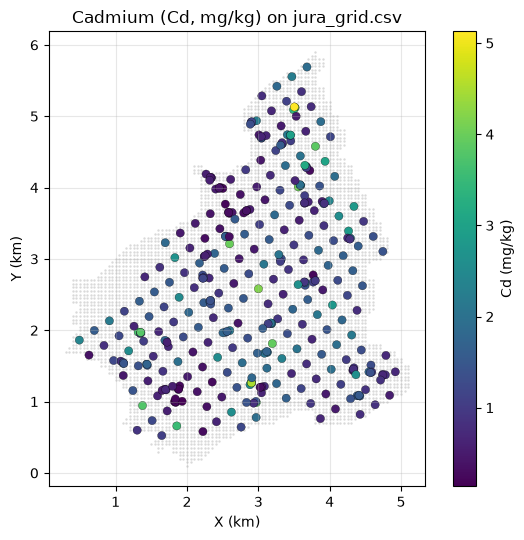

In [2]:
jura = pd.read_csv("../data/jura_data.csv", index_col=0)
grid = pd.read_csv("../data/jura_grid.csv", index_col=0)
coords = jura[["Xloc", "Yloc"]].to_numpy(dtype=float)
grid_pts = grid[["Xloc", "Yloc"]].to_numpy(dtype=float)
cd = jura["Cd"].to_numpy(dtype=float)

print(f"{len(jura)} samples; {len(grid)} prediction nodes")
print(f"Cd mean={cd.mean():.3f}, std={cd.std():.3f}, skew={pd.Series(cd).skew():.2f}")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(grid["Xloc"], grid["Yloc"], s=2, c="0.85", marker=".", label="prediction grid")
sc = ax.scatter(coords[:, 0], coords[:, 1], c=cd, cmap="viridis", s=35,
                edgecolor="k", linewidth=0.2, label="samples")
ax.set_xlabel("X (km)"); ax.set_ylabel("Y (km)")
ax.set_title("Cadmium (Cd, mg/kg) on jura_grid.csv")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="Cd (mg/kg)")
plt.tight_layout()
plt.show()

***
## 7. Step 1: Fit a Nested (Nugget + Short + Long) Variogram

`fit_nested_variogram` bins the experimental semivariogram and fits a nugget plus
two spherical structures by least squares. Jura's Cd variogram trends upward well
beyond ~3 km (a regional drift outside the scope of a simple bounded nested model),
so we fit only the well-behaved part, up to `maxlag=3.0` km.

nugget           = 0.5588
short-range (1)  : sill=0.0629, range=0.540 km
long-range  (2)  : sill=0.0857, range=1.449 km
total sill       = 0.7073  (sample variance = 0.7360)


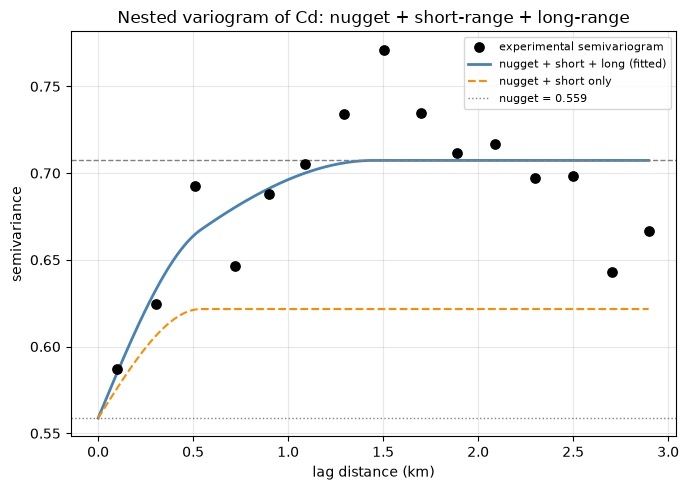

In [3]:
nugget, structures, lag_h, lag_g = fit_nested_variogram(
    coords, cd, models=("spherical", "spherical"), n_lags=15, maxlag=3.0
)
short, long_ = structures  # sorted short -> long range by fit_nested_variogram

print(f"nugget           = {nugget:.4f}")
print(f"short-range (1)  : sill={short['sill']:.4f}, range={short['range']:.3f} km")
print(f"long-range  (2)  : sill={long_['sill']:.4f}, range={long_['range']:.3f} km")
print(f"total sill       = {nugget + short['sill'] + long_['sill']:.4f}  (sample variance = {cd.var():.4f})")

h_fine = np.linspace(0, lag_h.max(), 300)


def spherical_gamma(h, sill, rng):
    u = np.clip(h / rng, 0, 1)
    return sill * (1.5 * u - 0.5 * u ** 3)


model_g = nugget + spherical_gamma(h_fine, short["sill"], short["range"]) + spherical_gamma(h_fine, long_["sill"], long_["range"])
nugget_short_g = nugget + spherical_gamma(h_fine, short["sill"], short["range"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(lag_h, lag_g, s=45, color="black", zorder=3, label="experimental semivariogram")
ax.plot(h_fine, model_g, color="steelblue", lw=2, label="nugget + short + long (fitted)")
ax.plot(h_fine, nugget_short_g, color="darkorange", lw=1.5, ls="--", label="nugget + short only")
ax.axhline(nugget, color="gray", ls=":", lw=1, label=f"nugget = {nugget:.3f}")
ax.axhline(nugget + short["sill"] + long_["sill"], color="gray", ls="--", lw=1)
ax.set_xlabel("lag distance (km)"); ax.set_ylabel("semivariance")
ax.set_title("Nested variogram of Cd: nugget + short-range + long-range")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **Reading this honestly.** The nugget dominates (~75-80% of the fitted sill),
> typical of trace-metal geochemical assays -- a lot of the variability in Cd
> happens below the shortest sampled distance. The two bounded structures are
> modest in amplitude but clearly separated in range (roughly a 2.5-3x ratio),
> which is enough for factorial kriging to tell them apart, as Section 10
> verifies quantitatively.

***
## 8. Step 2: Sanity Checks Before Trusting the Maps

Two properties should hold *exactly* (up to floating point), because they follow
directly from the linear-algebra structure of the kriging system, not from anything
about this particular data set:

1. `extract(factor='total')` is ordinary kriging of Cd -- an exact interpolator, so
   it must reproduce the data precisely at the data locations.
2. `extract(factor=[1,2])` (one solve with a combined right-hand side) must equal
   `extract(factor=1) + extract(factor=2)` (two separate solves), since both use the
   same neighbors and the same sum-to-zero constraint.

In [4]:
fk = FactorialKriging(nugget=nugget, structures=structures, max_neighbors=30, use_gpu=USE_GPU)
fk.fit(coords, cd)

z_hat_at_data = fk.extract(coords, factor="total")
print("max |OK estimate - true Cd| at data locations:", np.max(np.abs(z_hat_at_data - cd)))

check_pts = coords[:30]
combined = fk.extract(check_pts, factor=[1, 2])
separate = fk.extract(check_pts, factor=1) + fk.extract(check_pts, factor=2)
print("max |combined - (short + long)| :", np.max(np.abs(combined - separate)))

max |OK estimate - true Cd| at data locations: 4.808642550813147e-08
max |combined - (short + long)| : 5.551115123125783e-16


***
## 9. Step 3: Map the Total, Short-Range, and Long-Range Factors

We krige onto `jura_grid.csv` — the same prediction lattice as Tutorial 04
(~6 000 nodes covering the Jura domain) — and extract three views of the same
data: the ordinary-kriging estimate of Cd itself, the short-range factor alone, and
the long-range factor alone.

Prediction grid: 5957 nodes from jura_grid.csv


  total  min/mean/max : 0.440 / 1.320 / 2.426
  short  min/mean/max : -0.306 / 0.002 / 0.455
  long   min/mean/max : -0.241 / 0.008 / 0.309


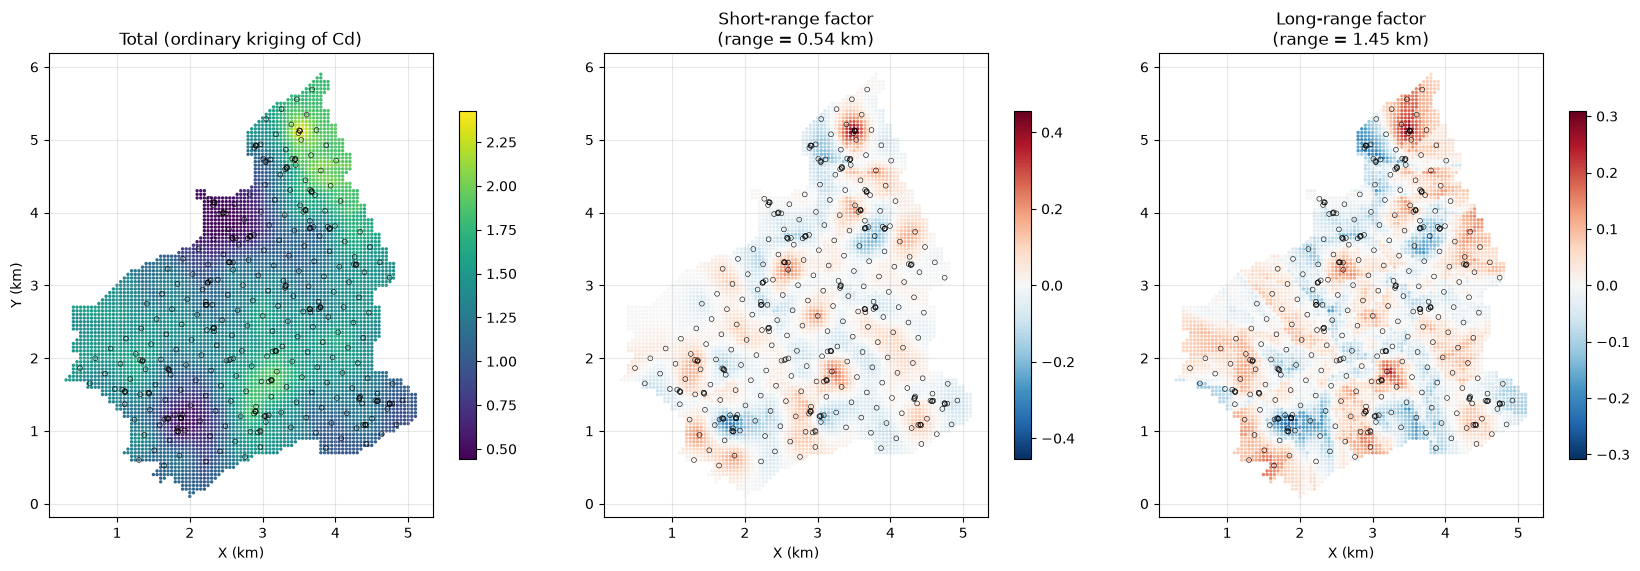

In [5]:
print(f"Prediction grid: {len(grid)} nodes from jura_grid.csv")

total_grid = fk.extract(grid_pts, factor="total")
short_grid = fk.extract(grid_pts, factor=1)
long_grid = fk.extract(grid_pts, factor=2)

print(f"  total  min/mean/max : {np.nanmin(total_grid):.3f} / {np.nanmean(total_grid):.3f} / {np.nanmax(total_grid):.3f}")
print(f"  short  min/mean/max : {np.nanmin(short_grid):.3f} / {np.nanmean(short_grid):.3f} / {np.nanmax(short_grid):.3f}")
print(f"  long   min/mean/max : {np.nanmin(long_grid):.3f} / {np.nanmean(long_grid):.3f} / {np.nanmax(long_grid):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
for ax, z, title, cmap, diverging in [
    (axes[0], total_grid, "Total (ordinary kriging of Cd)", "viridis", False),
    (axes[1], short_grid, f"Short-range factor\n(range = {short['range']:.2f} km)", "RdBu_r", True),
    (axes[2], long_grid, f"Long-range factor\n(range = {long_['range']:.2f} km)", "RdBu_r", True),
]:
    vmax = np.nanmax(np.abs(z)) if diverging else None
    sc = ax.scatter(
        grid["Xloc"], grid["Yloc"], c=z,
        cmap=cmap, s=8, marker=".",
        vmin=(-vmax if vmax else None), vmax=vmax,
    )
    ax.scatter(coords[:, 0], coords[:, 1], s=12, facecolors="none",
               edgecolors="k", linewidths=0.4)
    ax.set_title(title)
    ax.set_xlabel("X (km)")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, shrink=0.75)
axes[0].set_ylabel("Y (km)")
plt.tight_layout()
plt.show()

Notice the short-range map is visually "busier" -- more small, localized patches --
while the long-range map varies more smoothly and broadly across the domain. Both
are legitimate, mutually-uncorrelated slices of the same Cd variogram.

***
## 10. Step 4:  Quantify the Scale Separation

We check spatial autocorrelation at a lag comfortably inside the short structure's
own range: the long-range factor should still be clearly autocorrelated there,
while the short-range factor should have largely decorrelated.

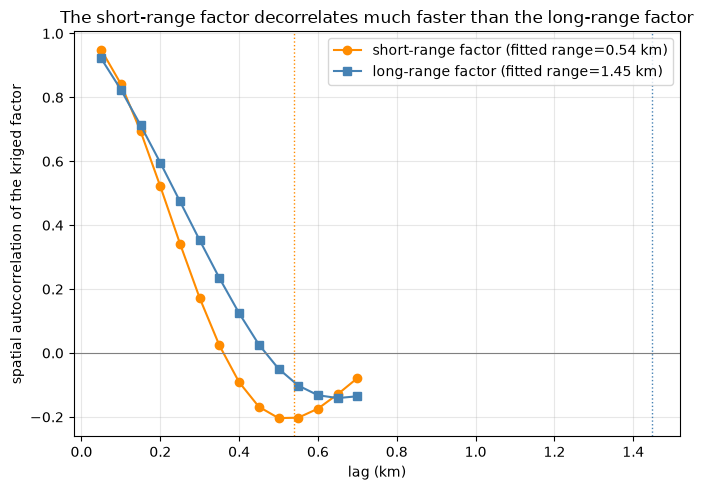

At lag 0.30 km: corr(short-range factor) = 0.172   corr(long-range factor) = 0.353


In [6]:
def pivot_to_array(x, y, z):
    """Reshape irregular lattice values onto the unique (x, y) mesh (NaN in holes)."""
    return (
        pd.DataFrame({"x": x, "y": y, "z": z})
        .pivot(index="y", columns="x", values="z")
        .sort_index()
        .sort_index(axis=1)
        .to_numpy()
    )


def lag_autocorr(grid_2d, k):
    a, b = grid_2d[:-k, :].ravel(), grid_2d[k:, :].ravel()
    m = np.isfinite(a) & np.isfinite(b)
    c1 = np.corrcoef(a[m], b[m])[0, 1]
    a2, b2 = grid_2d[:, :-k].ravel(), grid_2d[:, k:].ravel()
    m2 = np.isfinite(a2) & np.isfinite(b2)
    c2 = np.corrcoef(a2[m2], b2[m2])[0, 1]
    return (c1 + c2) / 2.0


short_2d = pivot_to_array(grid["Xloc"], grid["Yloc"], short_grid)
long_2d = pivot_to_array(grid["Xloc"], grid["Yloc"], long_grid)

gx = np.sort(grid["Xloc"].unique())
cell_size = float(np.median(np.diff(gx)))
lags_km = np.arange(1, 15) * cell_size
corr_short = [lag_autocorr(short_2d, k) for k in range(1, 15)]
corr_long = [lag_autocorr(long_2d, k) for k in range(1, 15)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lags_km, corr_short, "o-", color="darkorange", label=f"short-range factor (fitted range={short['range']:.2f} km)")
ax.plot(lags_km, corr_long, "s-", color="steelblue", label=f"long-range factor (fitted range={long_['range']:.2f} km)")
ax.axvline(short["range"], color="darkorange", ls=":", lw=1)
ax.axvline(long_["range"], color="steelblue", ls=":", lw=1)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("lag (km)"); ax.set_ylabel("spatial autocorrelation of the kriged factor")
ax.set_title("The short-range factor decorrelates much faster than the long-range factor")
ax.legend()
plt.tight_layout()
plt.show()

k_check = max(1, round(0.6 * short["range"] / cell_size))
lag_check = k_check * cell_size
cs, cl = lag_autocorr(short_2d, k_check), lag_autocorr(long_2d, k_check)
print(f"At lag {lag_check:.2f} km: corr(short-range factor) = {cs:.3f}   corr(long-range factor) = {cl:.3f}")

***
## 11. Step 5:  Filtering the Nugget: a Denoised Cd Map

`factor='denoised'` estimates Z with the nugget's noise spike removed from the target covariance, while keeping the sum=1 (mean-preserving) constraint -- so the result stays directly comparable to raw Cd, in the same units. (A separate `factor='signal'` gives the *pure, zero-mean* structured fluctuation in the strict Matheron sense -- useful for factor analysis, not for a like-for-like comparison with Z; see Section 4.)

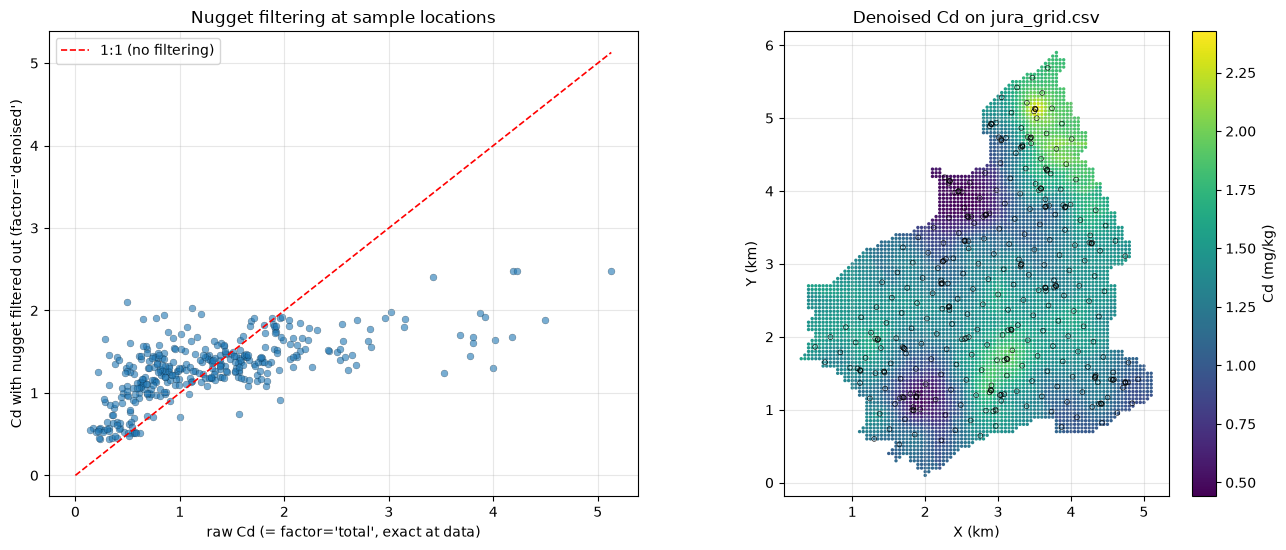

std(raw Cd) = 0.858   std(denoised Cd at same points) = 0.378   mean(raw) = 1.288   mean(denoised) = 1.289
denoised grid min/mean/max : 0.440 / 1.320 / 2.426


In [7]:
denoised_at_data = fk.extract(coords, factor="denoised")
denoised_grid = fk.extract(grid_pts, factor="denoised")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

axes[0].scatter(cd, denoised_at_data, s=25, alpha=0.6, edgecolor="k", linewidth=0.2)
lims = [0, max(cd.max(), denoised_at_data.max())]
axes[0].plot(lims, lims, "r--", lw=1.2, label="1:1 (no filtering)")
axes[0].set_xlabel("raw Cd (= factor='total', exact at data)")
axes[0].set_ylabel("Cd with nugget filtered out (factor='denoised')")
axes[0].set_title("Nugget filtering at sample locations")
axes[0].legend()

sc = axes[1].scatter(
    grid["Xloc"], grid["Yloc"], c=denoised_grid,
    cmap="viridis", s=8, marker=".",
)
axes[1].scatter(coords[:, 0], coords[:, 1], s=12, facecolors="none",
                edgecolors="k", linewidths=0.4)
plt.colorbar(sc, ax=axes[1], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_xlabel("X (km)"); axes[1].set_ylabel("Y (km)")
axes[1].set_title("Denoised Cd on jura_grid.csv")

plt.tight_layout()
plt.show()

print(f"std(raw Cd) = {cd.std():.3f}   std(denoised Cd at same points) = {denoised_at_data.std():.3f}   "
      f"mean(raw) = {cd.mean():.3f}   mean(denoised) = {denoised_at_data.mean():.3f}")
print(f"denoised grid min/mean/max : {np.nanmin(denoised_grid):.3f} / "
      f"{np.nanmean(denoised_grid):.3f} / {np.nanmax(denoised_grid):.3f}")

***
## 12. CPU vs GPU Factorial Kriging Timing

The 359-sample Jura survey is too small for a GPU comparison: the batched factorial-kriging solve is a stack of tiny $(k+1)\times(k+1)$ systems, and host→device copies dominate. Here we **simulate a Jura-like Cd field** with Sequential Gaussian Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$, then time **k-nearest-neighbor** factorial kriging (`search_radius=None`) on **CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`).

Simulation recipe (conditioned on the real 359 samples):

1. Draw $n_{\mathrm{train}} = 8{,}000$ random locations in the Jura bounding box.
2. Simulate $\log(\mathrm{Cd})$ with `sgsim` (exponential variogram, practical range 1.2 km, conditioned on `data/jura_data.csv`) and back-transform with $\exp(\cdot)$.
3. Draw a separate prediction set (no values needed — factorial kriging only needs coordinates plus the training data).

Unlike global ordinary kriging, the GPU work scales with **$n_{\mathrm{pred}}$** (one stacked solve of shape `(n_pred, k+1, k+1)` per `extract` call), not $n_{\mathrm{train}}^3$. Training size is therefore held at 8{,}000 and we vary $n_{\mathrm{pred}}$. Nested-variogram parameters are the **fitted Jura model from §7**, so fitting $\gamma$ is **not** in the times. Each timing is `fit` plus the mapping workload of §9: `extract(factor="total", return_variance=True)`, `extract(factor=1)`, and `extract(factor=2)`, with `max_neighbors=30`.

Each timing is the **median** of three `fit` + `extract` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped.


Simulating 8,000 Jura-like Cd locations with sgsim
  conditioning : 359 samples from data/jura_data.csv
  vario        : azimuth=0, nugget=0.023, range=1.2 km, exponential, log(Cd)
  sgsim wall   : 57.9 s  (not included in FactorialKriging times)
  simulated Cd : [0.13, 9.91] mg/kg  (Jura observed [0.14, 5.13])

GPU usable : True
Repeats    : 3  (median wall time of FactorialKriging fit + extract, k-NN)
n_train    : 8000  (sgsim Jura-like Cd)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the Jura bbox)
neighbors  : max_neighbors=30; nested model from §7 (359 Jura samples)

     dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
Jura (sgsim)     8000     500     172.4      25.7   6.71×   True
Jura (sgsim)     8000    1000     306.6      33.4   9.19×   True
Jura (sgsim)     8000    2000     612.3      53.9  11.36×   True
Jura (sgsim)     8000    4000    1331.8      99.7  13.36×   True
Jura (sgsim)     8000    8000    2785.1     187.1  14.88×   True



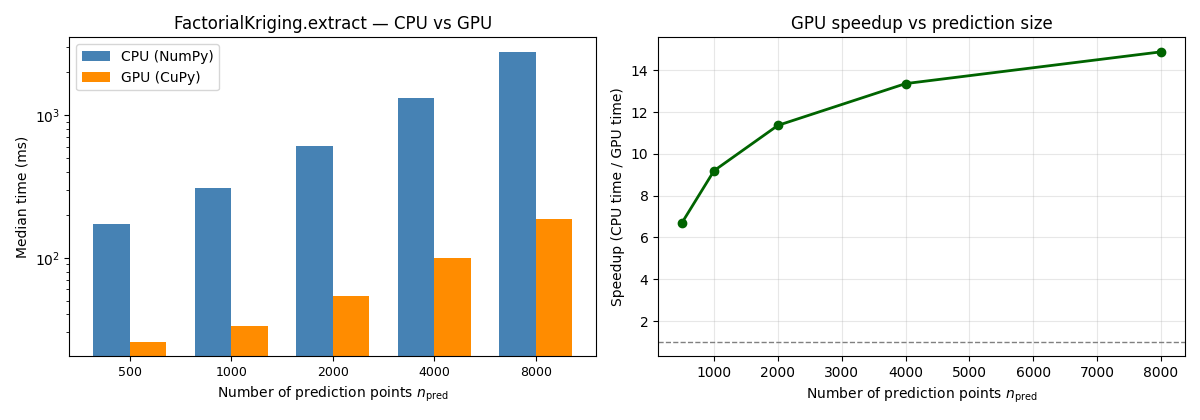

In [12]:
import time

N_REPEATS = 3
N_TRAIN = 8000
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
N_NEIGHBORS = 30
rng_sim = np.random.default_rng(42)

pad = 0.15
xmin, xmax = float(coords[:, 0].min()) - pad, float(coords[:, 0].max()) + pad
ymin, ymax = float(coords[:, 1].min()) - pad, float(coords[:, 1].max()) + pad

xy_train_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_TRAIN, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "log_cd": np.log(cd),
})
log_cd_var = float(np.var(np.log(cd)))
vario_sgs = [0, 0.05 * log_cd_var, 1.2, 1.2, log_cd_var, "exponential"]

print(f"Simulating {N_TRAIN:,} Jura-like Cd locations with sgsim")
print(f"  conditioning : {len(cd)} samples from data/jura_data.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=1.2 km, exponential, log(Cd)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_train_all, df_cond, "x", "y", "log_cd",
    num_points=12, vario=vario_sgs, radius=2.5,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
cd_sim = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in FactorialKriging times)")
print(f"  simulated Cd : [{cd_sim.min():.2f}, {cd_sim.max():.2f}] mg/kg"
      f"  (Jura observed [{cd.min():.2f}, {cd.max():.2f}])")
print()


def _extract_workload(fk, xy_pred):
    z_tot, var = fk.extract(xy_pred, factor="total", return_variance=True)
    z1 = fk.extract(xy_pred, factor=1)
    z2 = fk.extract(xy_pred, factor=2)
    return z_tot, var, z1, z2


def _time_fk(xy_train, z_train, xy_pred, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of FactorialKriging.fit + extract (k-NN, search_radius=None)."""
    kw = dict(
        nugget=nugget,
        structures=structures,
        max_neighbors=N_NEIGHBORS,
        search_radius=None,
        use_gpu=use_gpu,
    )
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        fk_w = FactorialKriging(**kw)
        fk_w.fit(xy_train[:k_tr], z_train[:k_tr])
        _extract_workload(fk_w, xy_pred[:k_pr])
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        fk = FactorialKriging(**kw)
        fk.fit(xy_train, z_train)
        last = _extract_workload(fk, xy_pred)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of FactorialKriging fit + extract, k-NN)")
print(f"n_train    : {N_TRAIN}  (sgsim Jura-like Cd)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the Jura bbox)")
print(f"neighbors  : max_neighbors={N_NEIGHBORS}; nested model from §7 (359 Jura samples)")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_fk(xy_train_all, cd_sim, xy_pr, use_gpu=False)
    row = {
        "dataset": "Jura (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_fk(xy_train_all, cd_sim, xy_pr, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        match = True
        for a, b in zip(pred_cpu, pred_gpu):
            match = match and bool(np.allclose(a, b, rtol=1e-4, atol=1e-4, equal_nan=True))
        row["match"] = match
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("FactorialKriging.extract — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Total, short-range, and long-range extracts (and the total kriging variance) from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, k+1, k+1)$ factorial-kriging solve, not from SGS (simulation is CPU sequential and is excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` with `search_radius=None` so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 13. Summary and Conclusions

- **`pygstat.factorial_kriging`** implements Matheron's Factorial Kriging Analysis:
  `fit_nested_variogram` fits a nugget + nested structures to data, and
  `FactorialKriging.extract(factor=...)` estimates any single structure (or sum of
  structures) using the *same* kriging matrix as ordinary kriging, only changing the
  right-hand side and the unbiasedness constraint (0 instead of 1).
- On Jura's Cd variogram (nugget-dominated, with a short-range structure at
  ~0.5 km and a longer-range structure at ~1.5 km), the two extracted factor maps
  on `jura_grid.csv` behave exactly as theory predicts: the short-range map
  decorrelates over a much
  shorter distance than the long-range map (confirmed quantitatively via lag
  autocorrelation), and both sum linearly (`extract([1,2]) == extract(1)+extract(2)`
  to machine precision) while `extract('total')` alone reproduces the exact
  ordinary-kriging estimate of Cd.
- `factor='signal'` (everything but the nugget) gives a **denoised** map -- a
  practical, direct use of factorial kriging as a spatial filter.
- An important caveat, worth remembering: summing *all* individually-extracted
  factors (nugget + every structure) does **not** reconstruct `extract('total')`
  exactly -- it reconstructs $Z$ minus OK's own locally-varying mean estimate. Use
  `factor='total'` whenever you actually want $Z(x_0)$ back.
- **CPU / GPU.** k-NN factorial kriging (`search_radius=None`, `use_gpu=USE_GPU`)
  batches every prediction point's $(k+1)\times(k+1)$ system into one stacked
  solve. On an SGS-simulated Jura-like Cd field ($n_{\mathrm{train}}=8{,}000$)
  the GPU is several times faster than CPU as $n_{\mathrm{pred}}$ grows; the 359-sample
  Jura survey itself is too small for that path to pay off.


***
## 14. Resources

### Key papers

| Paper | Contribution |
|---|---|
| Matheron, G. (1982). *Pour une analyse krigeante des données régionalisées*. Note N-732, Centre de Géostatistique, Fontainebleau. | Introduced factorial kriging |
| Sandjivy, L. (1984). The factorial kriging analysis of regionalized data: its application to geochemical prospecting. In *Geostatistics for Natural Resources Characterization*, Reidel. | The geochemical-prospecting application this notebook follows |

### Textbooks

| Reference | Notes |
|---|---|
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.), Ch. 5. Wiley. | Rigorous treatment, including the "factors don't sum to OK" subtlety |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*, Ch. 6. Oxford University Press. | Accessible worked examples |
| Wackernagel, H. (2003). *Multivariate Geostatistics* (3rd ed.). Springer. | The multivariate extension (regionalized factor analysis) |

### In this library

| Object | Role |
|---|---|
| `pygstat.factorial_kriging.FactorialKriging` | Extract any structure (or sum of structures) of a nested variogram model (`use_gpu` for k-NN) |
| `pygstat.factorial_kriging.fit_nested_variogram` | Fit a nugget + nested sum of structures to data |
| `tests/test_factorial_kriging_jura.py` | The automated test suite validating this module |
| `tests/test_factorial_kriging_gpu.py` | Batched k-NN / CPU–GPU dispatch tests |
